# Import Libraries

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Load data

In [149]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

# Merging data

In [150]:
df = sales_train.merge(items, on='item_id', how='left')
df = df.merge(item_categories, on='item_category_id', how='left')
df = df.merge(shops, on='shop_id', how='left')
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


# Feature Engineering

In [151]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Features depending on date

In [152]:
df['item_cnt_month'] = df.groupby(['date_block_num', 'shop_id', 'item_id'])['item_cnt_day'].transform('sum')

### Year, week, month, day of week, weekend

We give the model an explicit understanding of information about a specific point in time because it will not be able to establish patterns if we simply leave the date attribute

In [153]:
df['month'] = df['date'].dt.month          
df['year'] = df['date'].dt.year

## Season

In [154]:
def get_season_from_date(date):
    month = date.month  # date уже типа Timestamp
    if month in [12, 1, 2]:
        return "Зима"
    elif month in [3, 4, 5]:
        return "Весна"
    elif month in [6, 7, 8]:
        return "Лето"
    elif month in [9, 10, 11]:
        return "Осень"

df['season'] = df['date'].apply(get_season_from_date)

In [155]:
df['date'].apply(get_season_from_date)

0           Зима
1           Зима
2           Зима
3           Зима
4           Зима
           ...  
2935844    Осень
2935845    Осень
2935846    Осень
2935847    Осень
2935848    Осень
Name: date, Length: 2935849, dtype: object

### Cycle features

December is the 11th month and January is the 0th month, in this example it is clearly seen that the model will not understand that they are neighbors, so the months need to be transferred to an imaginary circle, where the sin values ​​will be the x values, and the cosine values ​​will be the y values, respectively.

In [156]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

### Lag and rolling statistics features

In [157]:
df['lag_1'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].shift(1)  
df['lag_2'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].shift(2)  
df['lag_12'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].shift(12)

In [158]:
df['rolling_3_median'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].transform(
            lambda x: x.rolling(3, min_periods=1).median())

In [159]:
df['rolling_6_median'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].transform(
            lambda x: x.rolling(6, min_periods=1).median())

## Groupping

In [160]:
df['item_avg_sales_month'] = df.groupby(['item_id', 'month', 'shop_id'])['item_cnt_month'].transform('median')

In [161]:
df['shop_item_avg'] = df.groupby(['shop_id', 'item_id'])['item_cnt_month'].transform('median')

## logarifm feature

why do we need a logarithm at all?

It's simple, on some days sales skyrocketed due to the release of popular games, for example, a logarithm can partially solve this problem

In [162]:
df = df[(df['item_price'] >= 0) & (df['item_cnt_month'] >= 0)]

In [163]:
df = df.copy()
df['log_item_cnt_month'] = df['item_cnt_month'].apply(lambda x: np.log(x) if x > 0 else np.nan)

## City

In [164]:
df['city'] = df['shop_name'].str.split().str[0]

In [165]:
df['city'].unique()

array(['Ярославль', 'Москва', 'Курск', 'Красноярск', 'Волжский',
       'Воронеж', 'Адыгея', 'Балашиха', '!Якутск', 'Коломна', 'Калуга',
       'Жуковский', 'Казань', 'Интернет-магазин', 'Уфа', 'Н.Новгород',
       'Чехов', 'Химки', 'Сургут', 'Тюмень', 'СПб', 'РостовНаДону',
       'Омск', 'Самара', 'Новосибирск', 'Сергиев', 'Вологда', 'Якутск',
       'Цифровой', 'Выездная', 'Томск', 'Мытищи'], dtype=object)

may be confusing digital and online store, but since these are separate categories and logically different places, then everything is fine

## Type of shop

In [166]:
df['type_of_shop'] = df['shop_name'].str.split().str[1]

In [167]:
df['type_of_shop'].unique()

array(['ТЦ', 'ТРК', 'ТК', 'Магазин', 'МТРЦ', '(Плехановская,', 'ТРЦ',
       'Орджоникидзе,', 'ул.', 'ЧС', 'Посад', 'склад', 'Торговля',
       '"Распродажа"'], dtype=object)

## Price changes

In [168]:
df.sort_values(['item_id', 'date'], inplace=True)
df.loc[:, 'price_change'] = df.groupby('item_id')['item_price'].diff()
df.loc[:, 'price_increasing'] = (df['price_change'] > 0).astype(int)
df.groupby('item_id')['price_increasing'].transform(lambda x: x.fillna(0))
df.drop(columns=['price_change'], inplace=True)

In [169]:
df['item_min_price'] = df.groupby('item_id')['item_price'].transform('min')
df['item_max_price'] = df.groupby('item_id')['item_price'].transform('max')

In [170]:
df['price_range'] = df['item_max_price'] - df['item_min_price']

In [171]:
df.columns

Index(['date', 'date_block_num', 'shop_id', 'item_id', 'item_price',
       'item_cnt_day', 'item_name', 'item_category_id', 'item_category_name',
       'shop_name', 'item_cnt_month', 'month', 'year', 'season', 'month_sin',
       'month_cos', 'lag_1', 'lag_2', 'lag_12', 'rolling_3_median',
       'rolling_6_median', 'item_avg_sales_month', 'shop_item_avg',
       'log_item_cnt_day', 'city', 'type_of_shop', 'price_increasing',
       'item_min_price', 'item_max_price', 'price_range'],
      dtype='object')

### Correlation

Text(0.5, 1.0, '')

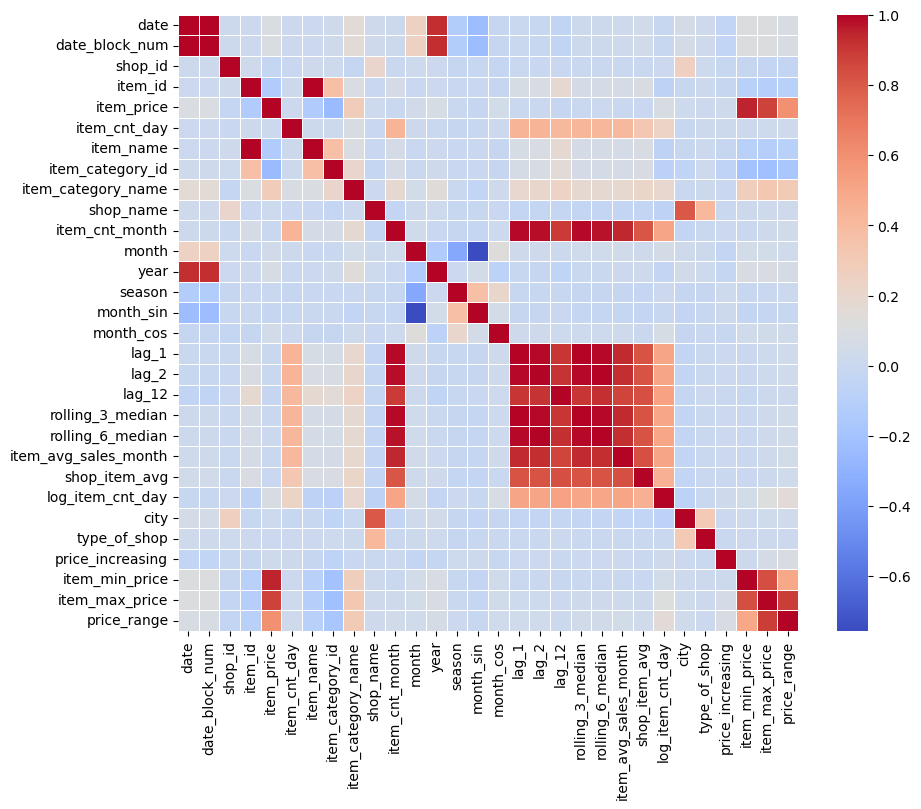

In [172]:
df_numeric = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df_numeric[col] = pd.factorize(df[col])[0]

corr = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
           cmap='coolwarm',
           annot=False,
           cbar=True,   
           linewidths=0.7)

plt.title('Feature correlation', pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title('')

In [138]:
df.to_csv('fe_df.csv')